In [15]:
import torch
import torchvision.transforms as transforms
from PIL import Image
import os
import torch.nn as nn

import matplotlib.pyplot as plt
import sys
sys.path.append('./models') 


import torch
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt

#

In [16]:
# convolution block with BatchNormalization
def ConvBlock(in_channels, out_channels, pool=False):
    layers = [nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
             nn.BatchNorm2d(out_channels),
             nn.ReLU(inplace=True)]
    if pool:
        layers.append(nn.MaxPool2d(4))
    return nn.Sequential(*layers)

In [17]:
class ImageClassificationBase(nn.Module):
    
    def training_step(self, batch):
        images, labels = batch 
        out = self(images)                  # Generate predictions
        loss = F.cross_entropy(out, labels) # Calculate loss
        return loss
    
    def validation_step(self, batch):
        images, labels = batch 
        out = self(images)                    # Generate predictions
        loss = F.cross_entropy(out, labels)   # Calculate loss
        acc = accuracy(out, labels)           # Calculate accuracy
        return {'val_loss': loss.detach(), 'val_acc': acc}
        
    def validation_epoch_end(self, outputs):
        batch_losses = [x['val_loss'] for x in outputs]
        epoch_loss = torch.stack(batch_losses).mean()   # Combine losses
        batch_accs = [x['val_acc'] for x in outputs]
        epoch_acc = torch.stack(batch_accs).mean()      # Combine accuracies
        return {'val_loss': epoch_loss.item(), 'val_acc': epoch_acc.item()}
    
    def epoch_end(self, epoch, result):
        print("Epoch [{}], train_loss: {:.4f}, val_loss: {:.4f}, val_acc: {:.4f}".format(
            epoch, result['train_loss'], result['val_loss'], result['val_acc']))

In [18]:
# resnet architecture 
class CNN_NeuralNet(ImageClassificationBase):
    def __init__(self, in_channels, num_diseases):
        super().__init__()
        
        self.conv1 = ConvBlock(in_channels, 64)
        self.conv2 = ConvBlock(64, 128, pool=True) 
        self.res1 = nn.Sequential(ConvBlock(128, 128), ConvBlock(128, 128))
        
        self.conv3 = ConvBlock(128, 256, pool=True) 
        self.conv4 = ConvBlock(256, 512, pool=True)
        #self.conv5 = ConvBlock(256, 256, pool=True)
        #self.conv6 = ConvBlock(256, 512, pool=True)
        #self.conv7 = ConvBlock(512, 512, pool=True)
        
        self.res2 = nn.Sequential(ConvBlock(512, 512), ConvBlock(512, 512))
        self.classifier = nn.Sequential(nn.MaxPool2d(4),
                                       nn.Flatten(),
                                       nn.Linear(512, num_diseases))
        
    def forward(self, x): # x is the loaded batch
        out = self.conv1(x)
        out = self.conv2(out)
        out = self.res1(out) + out
        out = self.conv3(out)
        out = self.conv4(out)
        #out = self.conv5(out)
        #out = self.conv6(out)
        #out = self.conv7(out)
        out = self.res2(out) + out
        out = self.classifier(out)
        return out        

In [19]:
# resnet architecture 
class CNN_NeuralNet(ImageClassificationBase):
    def __init__(self, in_channels, num_diseases):
        super().__init__()
        
        self.conv1 = ConvBlock(in_channels, 64)
        self.conv2 = ConvBlock(64, 128, pool=True) 
        self.res1 = nn.Sequential(ConvBlock(128, 128), ConvBlock(128, 128))
        
        self.conv3 = ConvBlock(128, 256, pool=True) 
        self.conv4 = ConvBlock(256, 512, pool=True)
        #self.conv5 = ConvBlock(256, 256, pool=True)
        #self.conv6 = ConvBlock(256, 512, pool=True)
        #self.conv7 = ConvBlock(512, 512, pool=True)
        
        self.res2 = nn.Sequential(ConvBlock(512, 512), ConvBlock(512, 512))
        self.classifier = nn.Sequential(nn.MaxPool2d(4),
                                       nn.Flatten(),
                                       nn.Linear(512, num_diseases))
        
    def forward(self, x): # x is the loaded batch
        out = self.conv1(x)
        out = self.conv2(out)
        out = self.res1(out) + out
        out = self.conv3(out)
        out = self.conv4(out)
        #out = self.conv5(out)
        #out = self.conv6(out)
        #out = self.conv7(out)
        out = self.res2(out) + out
        out = self.classifier(out)
        return out        

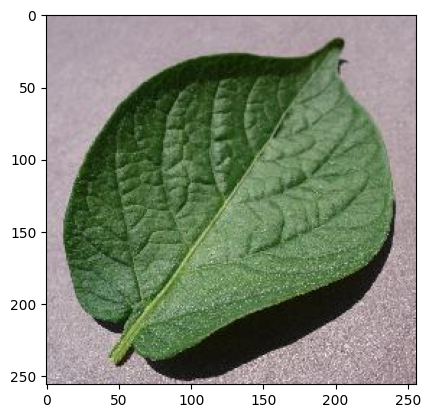

Predicted Class: Apple___Black_rot


In [32]:
import torch
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt

# Initialize the model
model = CNN_NeuralNet(3, 38)  # Ensure it matches the training model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the saved model weights
model.load_state_dict(torch.load('../models/disease_detection/model.pth'))
model.to(device)
model.eval()  # Set the model to evaluation mode

# Define class names (same as used during training)
class_names = ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 
               'Blueberry___healthy', 'Cherry_(including_sour)___healthy', 'Cherry_(including_sour)___Powdery_mildew', 
               'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 
               'Corn_(maize)___healthy', 'Corn_(maize)___Northern_Leaf_Blight', 'Grape___Black_rot', 
               'Grape___Esca_(Black_Measles)', 'Grape___healthy', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 
               'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 
               'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___healthy', 
               'Potato___Late_blight', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 
               'Strawberry___healthy', 'Strawberry___Leaf_scorch', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 
               'Tomato___healthy', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 
               'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_mosaic_virus', 
               'Tomato___Tomato_Yellow_Leaf_Curl_Virus']

# Define the transformations (same as during training)
transform = transforms.Compose([
    transforms.Resize((256, 256)),  # Resize image to 224x224 (same as training input)
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Load and transform the image
image_path = '../data/Leaf/test/PotatoHealthy2.jpg'  # Replace with your image path
image = Image.open(image_path).convert('RGB')
input_tensor = transform(image).unsqueeze(0).to(device)  # Add batch dimension and move to device

# Make a prediction
with torch.no_grad():
    output = model(input_tensor)
    probabilities = torch.nn.functional.softmax(output[0], dim=0)
    predicted_class = torch.argmax(probabilities).item()
    predicted_class_name = class_names[predicted_class]

# Display the image and predicted class
plt.imshow(image)
plt.show()
print(f'Predicted Class: {predicted_class_name}')


  0%|          | 0/10000 [00:00<?, ?it/s]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..207.0].


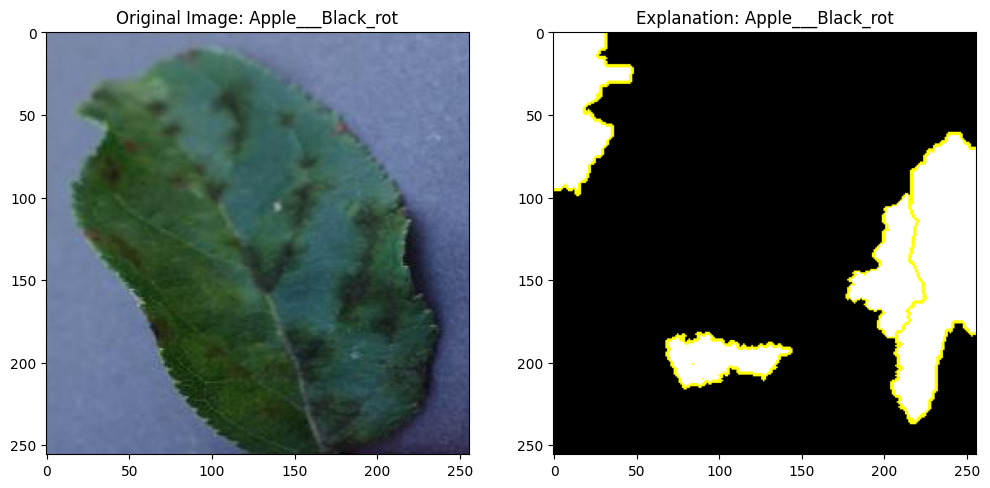

Predicted Class: Apple___Black_rot


In [40]:
import torch
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from lime import lime_image
from skimage.segmentation import mark_boundaries

# Initialize the model
model = CNN_NeuralNet(3, 38)  # Ensure it matches the training model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the saved model weights
model.load_state_dict(torch.load('../models/disease_detection/model.pth'))
model.to(device)
model.eval()  # Set the model to evaluation mode

# Define class names (same as used during training)
class_names = ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 
               'Blueberry___healthy', 'Cherry_(including_sour)___healthy', 'Cherry_(including_sour)___Powdery_mildew', 
               'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 
               'Corn_(maize)___healthy', 'Corn_(maize)___Northern_Leaf_Blight', 'Grape___Black_rot', 
               'Grape___Esca_(Black_Measles)', 'Grape___healthy', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 
               'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 
               'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___healthy', 
               'Potato___Late_blight', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 
               'Strawberry___healthy', 'Strawberry___Leaf_scorch', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 
               'Tomato___healthy', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 
               'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_mosaic_virus', 
               'Tomato___Tomato_Yellow_Leaf_Curl_Virus']

# Define the transformations (same as during training)
transform = transforms.Compose([
    transforms.Resize((256, 256)),  # Resize image to 256x256 (same as training input)
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Load and transform the image
image_path = '../data/Leaf/test/AppleScab2.jpg'  # Replace with your image path
image = Image.open(image_path).convert('RGB')
input_tensor = transform(image).unsqueeze(0).to(device)  # Add batch dimension and move to device

# Create a wrapper function for LIME's expected input format
def predict_fn(images):
    # Transform the image and move it to the same device as the model
    transformed_images = [transform(Image.fromarray(image)).unsqueeze(0).to(device) for image in images]
    
    # Make predictions for the batch of images
    with torch.no_grad():
        outputs = [model(img) for img in transformed_images]
        probabilities = [torch.nn.functional.softmax(output[0], dim=0).cpu().numpy() for output in outputs]
    
    return np.array(probabilities)

# Initialize LIME image explainer
# Ensure the image is in a valid format for LIME
image_np = np.array(image)

# Initialize LIME image explainer
explainer = lime_image.LimeImageExplainer()

# Explain the model's prediction for the test image
explanation = explainer.explain_instance(image_np, predict_fn, top_labels=5, hide_color=255, num_samples=10000)

# Get the explanation for the predicted class
predicted_class = torch.argmax(torch.nn.functional.softmax(model(input_tensor)[0], dim=0)).item()

# Get the explanation mask with more features
temp, mask = explanation.get_image_and_mask(predicted_class, positive_only=False, num_features=10, hide_rest=True)

# Display the image with LIME's explanation
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(image)
ax[0].set_title(f"Original Image: {class_names[predicted_class]}")
ax[1].imshow(mark_boundaries(temp, mask))
ax[1].set_title(f"Explanation: {class_names[predicted_class]}")
plt.show()

# Print the predicted class label


# Print the predicted class label
print(f'Predicted Class: {class_names[predicted_class]}')


  0%|          | 0/1000 [00:00<?, ?it/s]

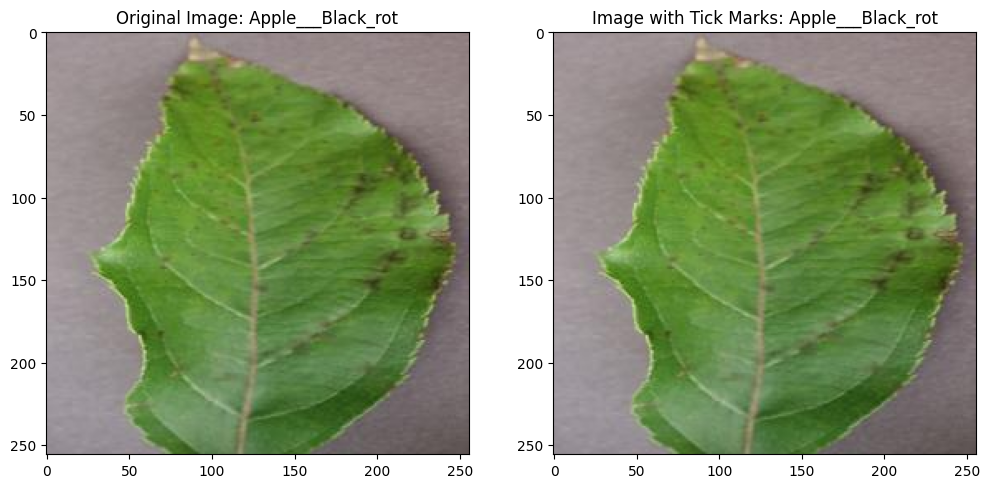

Predicted Class: Apple___Black_rot


In [41]:
import numpy as np
import matplotlib.pyplot as plt
from lime import lime_image
from skimage.segmentation import mark_boundaries
from PIL import Image

# Load and transform the image as you did earlier
image_path = '../data/Leaf/test/AppleScab1.jpg'  # Replace with your actual image path
image = Image.open(image_path).convert('RGB')
image_np = np.array(image)

# Define your prediction function (same as before)
def predict_fn(images):
    images = torch.tensor(images).permute(0, 3, 1, 2).float().to(device)  # Move to correct format for model
    with torch.no_grad():
        output = model(images)
    return torch.nn.functional.softmax(output, dim=1).cpu().numpy()

# Initialize LIME Image Explainer
explainer = lime_image.LimeImageExplainer()

# Explain the model's prediction for the test image
explanation = explainer.explain_instance(image_np, predict_fn, top_labels=5, hide_color=0, num_samples=1000)

# Get the explanation mask for the predicted class
predicted_class = torch.argmax(torch.nn.functional.softmax(model(input_tensor)[0], dim=0)).item()
temp, mask = explanation.get_image_and_mask(predicted_class, positive_only=True, num_features=10, hide_rest=True)

# Create tick marks or other markers in the affected regions
def overlay_ticks_on_image(image, mask):
    """Overlay tick marks on the affected areas"""
    # Get the coordinates of the non-zero elements in the mask (affected areas)
    affected_pixels = np.where(mask > 0)
    
    # Convert to a 2D array for visualization
    for i, j in zip(*affected_pixels):
        image[i, j] = np.array([255, 0, 0])  # Change this to a color you prefer for tick marks
    
    return image

# Overlay tick marks on the image
image_with_ticks = overlay_ticks_on_image(image_np.copy(), mask)

# Display the original and the processed image with tick marks
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(image)
ax[0].set_title(f"Original Image: {class_names[predicted_class]}")
ax[1].imshow(image_with_ticks)
ax[1].set_title(f"Image with Tick Marks: {class_names[predicted_class]}")
plt.show()

# Print the predicted class label
print(f'Predicted Class: {class_names[predicted_class]}')


  0%|          | 0/100 [00:00<?, ?it/s]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..224.0].


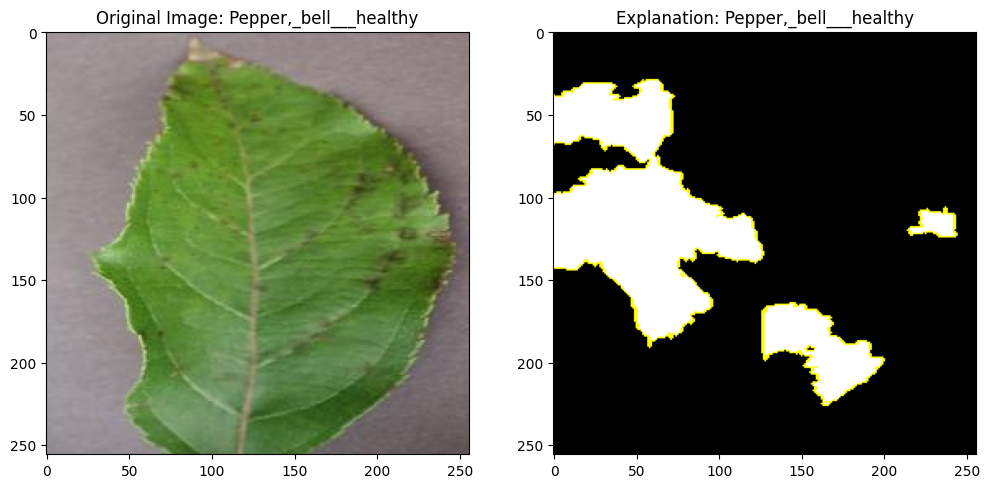

Predicted Class: Pepper,_bell___healthy


In [42]:
import torch
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from lime import lime_image
from skimage.segmentation import mark_boundaries

# Initialize the model
model = CNN_NeuralNet(3, 38)  # Ensure it matches the training model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the saved model weights
model.load_state_dict(torch.load('../models/disease_detection/model.pth'))
model.to(device)
model.eval()  # Set the model to evaluation mode

# Define class names (same as used during training)
class_names = ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 
               'Blueberry___healthy', 'Cherry_(including_sour)___healthy', 'Cherry_(including_sour)___Powdery_mildew', 
               'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 
               'Corn_(maize)___healthy', 'Corn_(maize)___Northern_Leaf_Blight', 'Grape___Black_rot', 
               'Grape___Esca_(Black_Measles)', 'Grape___healthy', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 
               'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 
               'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___healthy', 
               'Potato___Late_blight', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 
               'Strawberry___healthy', 'Strawberry___Leaf_scorch', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 
               'Tomato___healthy', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 
               'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_mosaic_virus', 
               'Tomato___Tomato_Yellow_Leaf_Curl_Virus']

# Define the transformations (same as during training)
transform = transforms.Compose([
    transforms.Resize((256, 256)),  # Resize image to 256x256 (same as training input)
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Load and transform the image
image_path = '../data/Leaf/test/AppleScab1.jpg'  # Replace with your image path
image = Image.open(image_path).convert('RGB')
input_tensor = transform(image).unsqueeze(0).to(device)  # Add batch dimension and move to device

# Create a wrapper function for LIME's expected input format
def predict_fn(images):
    # Transform the image and move it to the same device as the model
    transformed_images = [transform(Image.fromarray(image)).unsqueeze(0).to(device) for image in images]
    
    # Make predictions for the batch of images
    with torch.no_grad():
        outputs = [model(img) for img in transformed_images]
        probabilities = [torch.nn.functional.softmax(output[0], dim=0).cpu().numpy() for output in outputs]
    
    return np.array(probabilities)

# Initialize LIME image explainer
# Ensure the image is in a valid format for LIME
image_np = np.array(image)

# Initialize LIME image explainer
explainer = lime_image.LimeImageExplainer()

# Explain the model's prediction for the test image
explanation = explainer.explain_instance(image_np, predict_fn, top_labels=5, hide_color=255, num_samples=100)

# Get the explanation for the predicted class
predicted_class = torch.argmax(torch.nn.functional.softmax(model(input_tensor)[0], dim=0)).item()

# Get the explanation mask with more features
temp, mask = explanation.get_image_and_mask(predicted_class, positive_only=False, num_features=10, hide_rest=True)

# Display the image with LIME's explanation
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(image)
ax[0].set_title(f"Original Image: {class_names[predicted_class]}")
ax[1].imshow(mark_boundaries(temp, mask))
ax[1].set_title(f"Explanation: {class_names[predicted_class]}")
plt.show()

# Print the predicted class label


# Print the predicted class label
print(f'Predicted Class: {class_names[predicted_class]}')
